In [7]:
# Stock configuration — no separate file needed
STOCKS = {
    'AAPL' : 'Apple Inc.',
    'MSFT' : 'Microsoft',
    'GOOGL': 'Alphabet',
    'TSLA' : 'Tesla',
    'AMZN' : 'Amazon',
    'NVDA' : 'Nvidia',
}

START_DATE = '2020-01-01'

print("Configuration loaded")
print(f"Stocks to analyze: {list(STOCKS.keys())}")
print(f"Start date: {START_DATE}")

Configuration loaded
Stocks to analyze: ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'AMZN', 'NVDA']
Start date: 2020-01-01


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np

def download_all_stocks(stocks, start):
    all_data = {}
    for ticker in stocks.keys():
        print(f"Downloading {ticker}...")
        data = yf.download(ticker, start=start)
        if data.columns.nlevels > 1:
            data.columns = [col[0] for col in data.columns]
        all_data[ticker] = data
        print(f" {ticker}: {len(data)} rows")
    return all_data

# Run it
all_data = download_all_stocks(STOCKS, START_DATE)
print(f"\n All {len(all_data)} stocks downloaded successfully")

[*********************100%***********************]  1 of 1 completed


 AAPL: 1562 rows


[*********************100%***********************]  1 of 1 completed


 MSFT: 1562 rows


[*********************100%***********************]  1 of 1 completed


...

 TSLA: 1562 rows


[*********************100%***********************]  1 of 1 completed


 AMZN: 1562 rows


[*********************100%***********************]  1 of 1 completed

 NVDA: 1562 rows

 All 6 stocks downloaded successfully


In [11]:
import ta

def engineer_features(data):
    # Basic indicators
    data['MA50']    = data['Close'].rolling(50).mean()
    data['MA200']   = data['Close'].rolling(200).mean()
    data['Returns'] = data['Close'].pct_change()

    # Technical indicators
    data['RSI']         = ta.momentum.RSIIndicator(
                          data['Close']).rsi()
    macd                = ta.trend.MACD(data['Close'])
    data['MACD']        = macd.macd()
    data['MACD_Signal'] = macd.macd_signal()
    data['MACD_Diff']   = macd.macd_diff()
    bb                  = ta.volatility.BollingerBands(
                          data['Close'])
    data['BB_High']     = bb.bollinger_hband()
    data['BB_Low']      = bb.bollinger_lband()
    data['BB_Width']    = bb.bollinger_wband()
    data['ATR']         = ta.volatility.AverageTrueRange(
                          data['High'],
                          data['Low'],
                          data['Close']
                          ).average_true_range()

    # Feature engineering
    data['Target']         = (data['Close'].shift(-1) > 
                              data['Close']).astype(int)
    data['Daily_Range']    = data['High'] - data['Low']
    data['MA50_Distance']  = data['Close'] - data['MA50']
    data['MA200_Distance'] = data['Close'] - data['MA200']
    data['Volume_Change']  = data['Volume'].pct_change()
    data['Returns_Lag1']   = data['Returns'].shift(1)
    data['Returns_Lag2']   = data['Returns'].shift(2)
    data['Returns_Lag3']   = data['Returns'].shift(3)
    data['Volatility_5d']  = data['Returns'].rolling(5).std()
    data['Day_of_Week']    = data.index.dayofweek

    return data.dropna()

# Apply to all stocks
engineered_data = {}
for ticker, data in all_data.items():
    engineered_data[ticker] = engineer_features(data.copy())
    print(f" {ticker} features done: {engineered_data[ticker].shape}")

 AAPL features done: (1363, 26)
 MSFT features done: (1363, 26)
 GOOGL features done: (1363, 26)
 TSLA features done: (1363, 26)
 AMZN features done: (1363, 26)
 NVDA features done: (1363, 26)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

FEATURES = [
    'MA50', 'MA200', 'Returns',
    'Daily_Range', 'MA50_Distance', 'MA200_Distance',
    'Volume_Change', 'Returns_Lag1', 'Returns_Lag2',
    'Returns_Lag3', 'Volatility_5d', 'RSI',
    'MACD', 'MACD_Signal', 'MACD_Diff',
    'BB_High', 'BB_Low', 'BB_Width',
    'ATR', 'Day_of_Week'
]

def train_stock_model(data, ticker):
    X = data[FEATURES]
    y = data['Target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_train_scaled, y_train)
    preds    = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, preds)

    # Tomorrow's prediction
    latest        = data[FEATURES].iloc[-1:]
    latest_scaled = scaler.transform(latest)
    prediction    = model.predict(latest_scaled)[0]
    probability   = model.predict_proba(latest_scaled)[0]

    return {
        'ticker'    : ticker,
        'model'     : model,
        'scaler'    : scaler,
        'accuracy'  : accuracy,
        'prediction': prediction,
        'prob_up'   : probability[1],
        'prob_down' : probability[0],
        'last_close': data['Close'].iloc[-1]
    }

# Train models for all stocks
results = {}
for ticker, data in engineered_data.items():
    print(f"Training model for {ticker}...")
    results[ticker] = train_stock_model(data, ticker)
    print(f" {ticker} accuracy: {results[ticker]['accuracy']:.2%}")

Training model for AAPL...
 AAPL accuracy: 50.92%
Training model for MSFT...
 MSFT accuracy: 46.52%
Training model for GOOGL...
 GOOGL accuracy: 46.89%
Training model for TSLA...
 TSLA accuracy: 46.89%
Training model for AMZN...
 AMZN accuracy: 52.01%
Training model for NVDA...
 NVDA accuracy: 53.11%


In [13]:
def rank_stocks(results):
    rankings = []
    for ticker, result in results.items():
        rankings.append({
            'Ticker'    : ticker,
            'Last Close': f"${result['last_close']:.2f}",
            'Direction' : '🟢 UP' if result['prediction'] == 1
                          else '🔴 DOWN',
            'UP Prob'   : f"{result['prob_up']:.2%}",
            'DOWN Prob' : f"{result['prob_down']:.2%}",
            'Accuracy'  : f"{result['accuracy']:.2%}",
            'Confidence': result['prob_up'] 
                          if result['prediction'] == 1
                          else result['prob_down']
        })

    df = pd.DataFrame(rankings)
    df = df.sort_values('Confidence', ascending=False)
    return df

# Generate rankings
rankings_df = rank_stocks(results)

print("=" * 65)
print("        MULTI-STOCK PREDICTION RANKINGS")
print("=" * 65)
print(rankings_df.drop(columns='Confidence').to_string(index=False))
print("=" * 65)
print(f"\n BEST BUY TOMORROW : {rankings_df.iloc[0]['Ticker']}")
print(f"   Direction         : {rankings_df.iloc[0]['Direction']}")
print(f"   Confidence        : {rankings_df.iloc[0]['UP Prob']}")
print(f"   Last Close        : {rankings_df.iloc[0]['Last Close']}")

        MULTI-STOCK PREDICTION RANKINGS
Ticker Last Close Direction UP Prob DOWN Prob Accuracy
  NVDA    $172.70      🟢 UP  75.42%    24.58%   53.11%
  MSFT    $381.87      🟢 UP  66.71%    33.29%   46.52%
  AAPL    $247.99      🟢 UP  64.43%    35.57%   50.92%
  TSLA    $367.96    🔴 DOWN  42.77%    57.23%   46.89%
 GOOGL    $301.00      🟢 UP  53.16%    46.84%   46.89%
  AMZN    $205.37    🔴 DOWN  47.24%    52.76%   52.01%

 BEST BUY TOMORROW : NVDA
   Direction         : 🟢 UP
   Confidence        : 75.42%
   Last Close        : $172.70


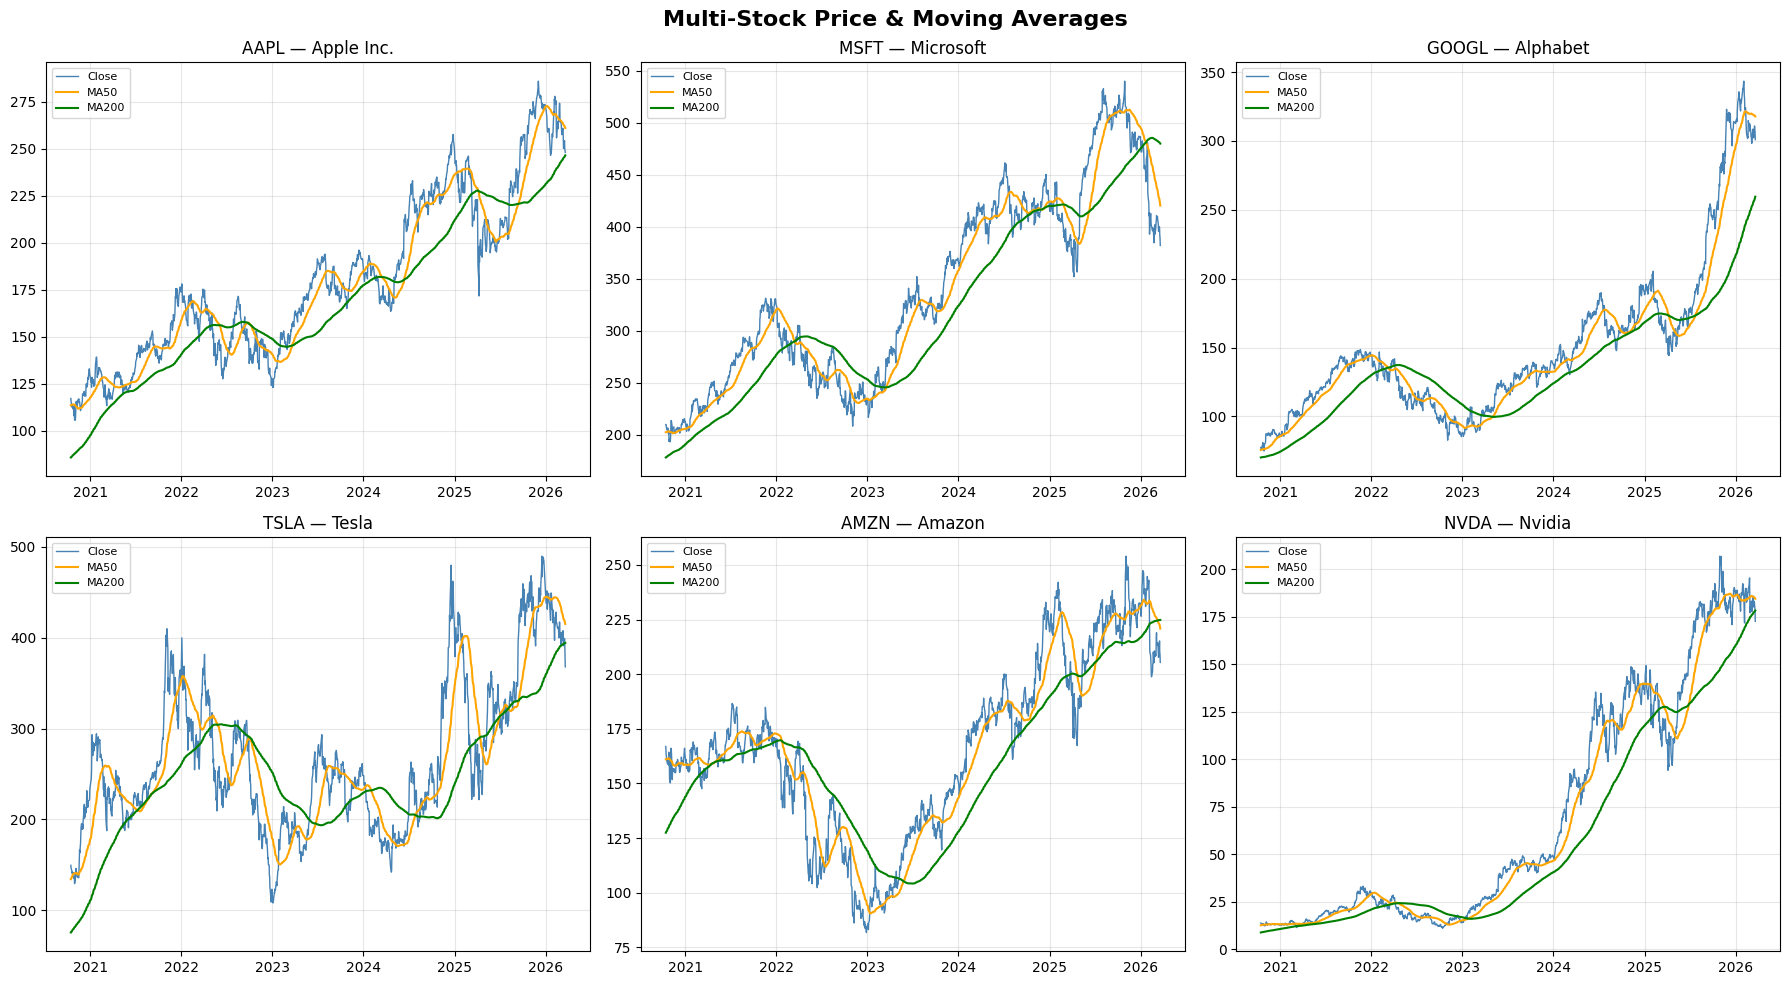

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (ticker, data) in enumerate(engineered_data.items()):
    ax = axes[idx]
    ax.plot(data.index, data['Close'],
            label='Close', color='steelblue', linewidth=1)
    ax.plot(data.index, data['MA50'],
            label='MA50', color='orange', linewidth=1.5)
    ax.plot(data.index, data['MA200'],
            label='MA200', color='green', linewidth=1.5)
    ax.set_title(f"{ticker} — {STOCKS[ticker]}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Stock Price & Moving Averages',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

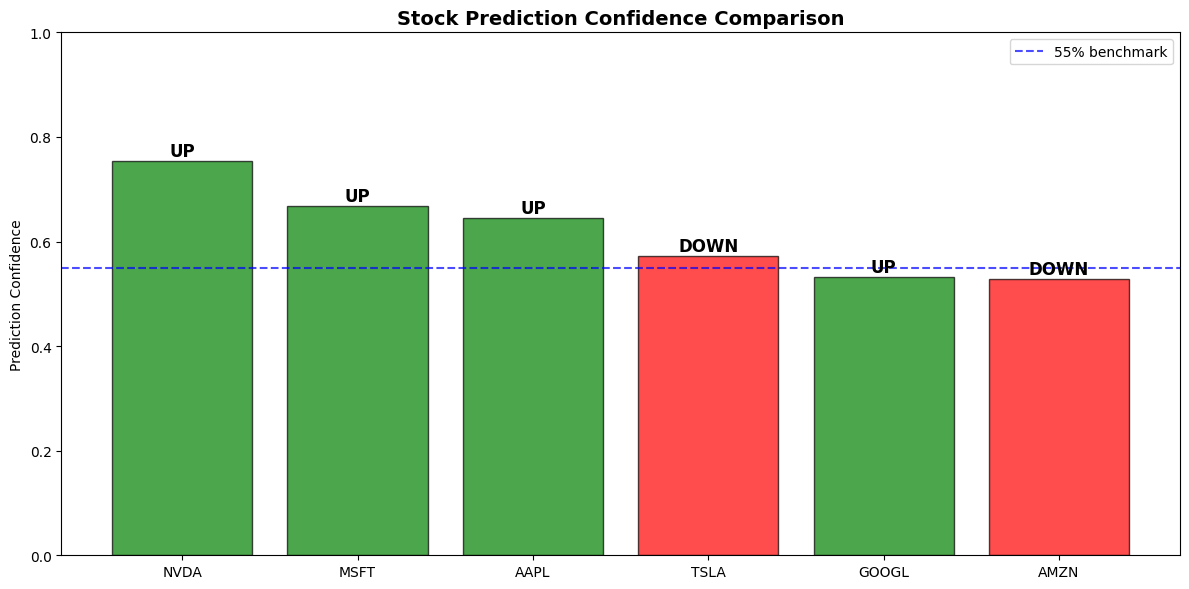

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

# Use text instead of emojis
direction_labels = {
    ticker: 'UP' if results[ticker]['prediction'] == 1 
    else 'DOWN' 
    for ticker in rankings_df['Ticker']
}

colors = [
    'green' if results[t]['prediction'] == 1 
    else 'red' 
    for t in rankings_df['Ticker']
]

bars = ax.bar(
    rankings_df['Ticker'],
    rankings_df['Confidence'],
    color=colors,
    alpha=0.7,
    edgecolor='black'
)

ax.axhline(
    y=0.55, color='blue', 
    linestyle='--', alpha=0.7, 
    label='55% benchmark'
)

ax.set_title(
    'Stock Prediction Confidence Comparison',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('Prediction Confidence')
ax.set_ylim(0, 1)
ax.legend()

# Add labels on top of bars
for bar, (_, row) in zip(bars, rankings_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        direction_labels[row['Ticker']],  # ← text instead of emoji
        ha='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

     PRICE CORRELATION MATRIX
       AAPL  MSFT  GOOGL  TSLA  AMZN  NVDA
AAPL   1.00  0.89   0.88  0.67  0.72  0.93
MSFT   0.89  1.00   0.80  0.55  0.78  0.93
GOOGL  0.88  0.80   1.00  0.75  0.79  0.88
TSLA   0.67  0.55   0.75  1.00  0.67  0.61
AMZN   0.72  0.78   0.79  0.67  1.00  0.82
NVDA   0.93  0.93   0.88  0.61  0.82  1.00


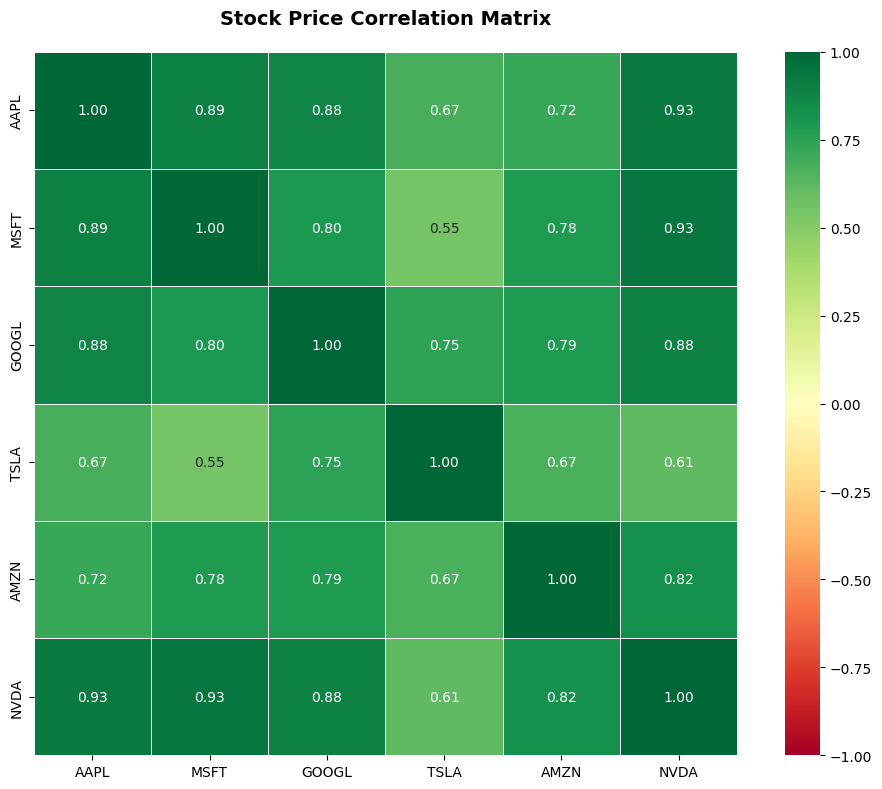

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract closing prices for all stocks
close_prices = pd.DataFrame({
    ticker: data['Close'] 
    for ticker, data in engineered_data.items()
})

# Calculate correlation matrix
price_corr = close_prices.corr()

print("=" * 50)
print("     PRICE CORRELATION MATRIX")
print("=" * 50)
print(price_corr.round(2))

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    price_corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    'Stock Price Correlation Matrix',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.show()

     RETURNS CORRELATION MATRIX
       AAPL  MSFT  GOOGL  TSLA  AMZN  NVDA
AAPL   1.00  0.61   0.56  0.48  0.56  0.51
MSFT   0.61  1.00   0.62  0.41  0.64  0.62
GOOGL  0.56  0.62   1.00  0.40  0.61  0.52
TSLA   0.48  0.41   0.40  1.00  0.44  0.46
AMZN   0.56  0.64   0.61  0.44  1.00  0.55
NVDA   0.51  0.62   0.52  0.46  0.55  1.00


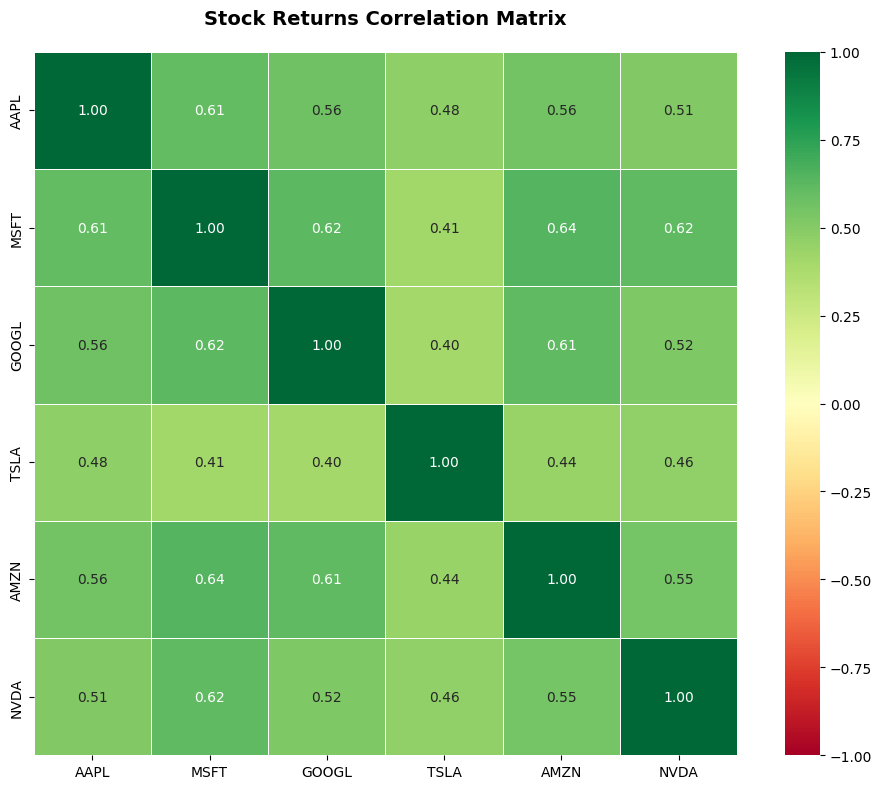

In [18]:
# Extract returns for all stocks
returns_all = pd.DataFrame({
    ticker: data['Returns'] 
    for ticker, data in engineered_data.items()
})

# Calculate correlation matrix
returns_corr = returns_all.corr()

print("=" * 50)
print("     RETURNS CORRELATION MATRIX")
print("=" * 50)
print(returns_corr.round(2))

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    returns_corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    'Stock Returns Correlation Matrix',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.show()

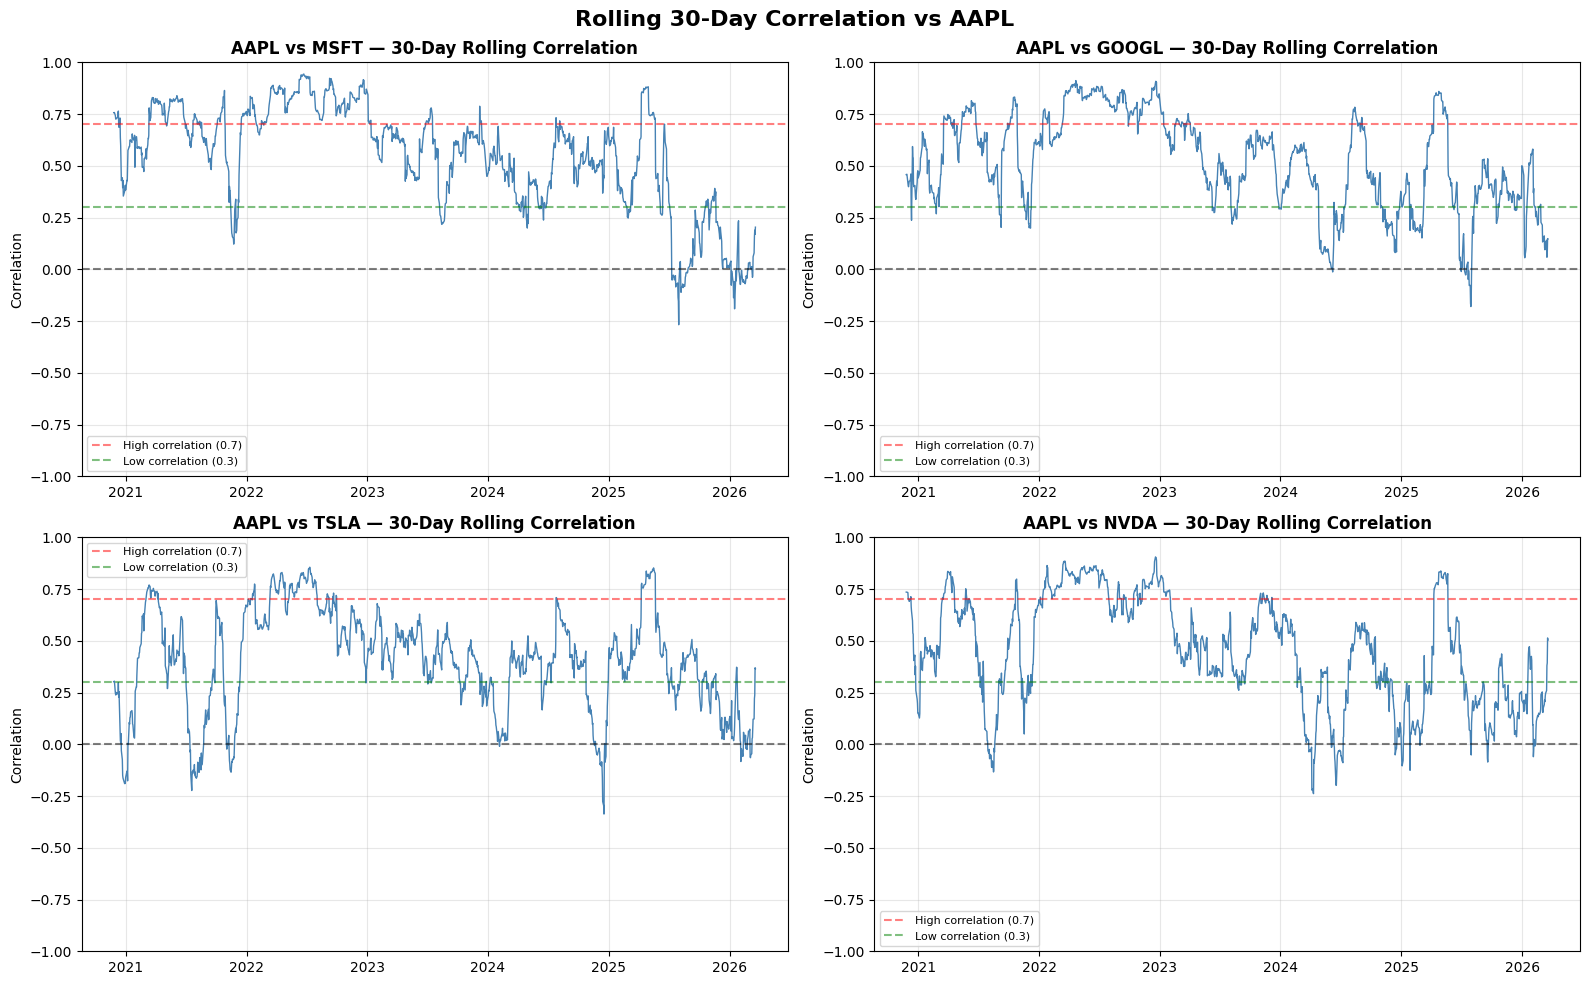

In [19]:
# Rolling 30-day correlation against AAPL
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

other_stocks = ['MSFT', 'GOOGL', 'TSLA', 'AMZN', 'NVDA']
pairs        = ['MSFT', 'GOOGL', 'TSLA', 'NVDA']

for idx, stock in enumerate(pairs):
    rolling_corr = returns_all['AAPL'].rolling(30).corr(
                   returns_all[stock])

    axes[idx].plot(
        rolling_corr.index,
        rolling_corr.values,
        color='steelblue', linewidth=1
    )
    axes[idx].axhline(
        y=0, color='black',
        linestyle='--', alpha=0.5
    )
    axes[idx].axhline(
        y=0.7, color='red',
        linestyle='--', alpha=0.5,
        label='High correlation (0.7)'
    )
    axes[idx].axhline(
        y=0.3, color='green',
        linestyle='--', alpha=0.5,
        label='Low correlation (0.3)'
    )
    axes[idx].set_title(
        f'AAPL vs {stock} — 30-Day Rolling Correlation',
        fontweight='bold'
    )
    axes[idx].set_ylabel('Correlation')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1, 1)

plt.suptitle(
    'Rolling 30-Day Correlation vs AAPL',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()
plt.show()

   ANNUALIZED VOLATILITY RANKING
Ticker  Annual Vol
  TSLA   59.877886
  NVDA   51.160143
  AMZN   34.776000
 GOOGL   30.701234
  AAPL   27.942058
  MSFT   26.083008


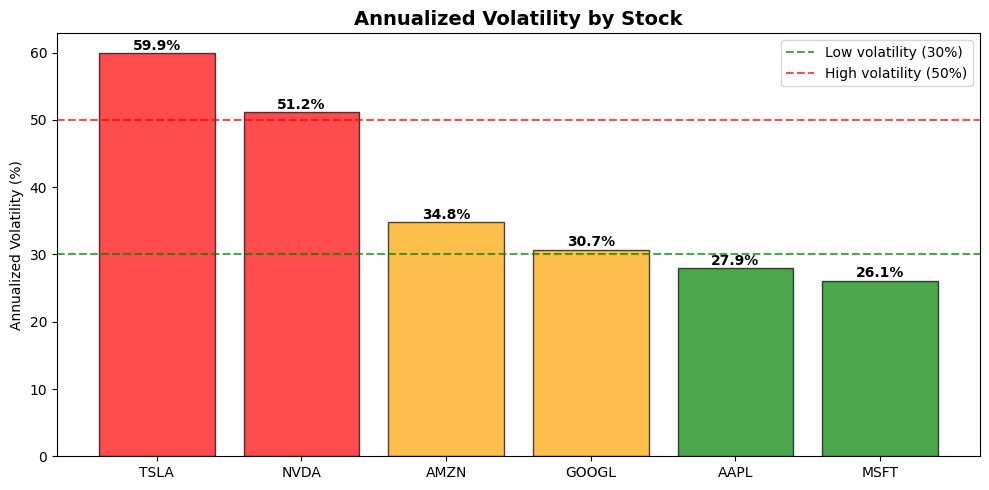

In [20]:
# Compare volatility across all stocks
volatility = returns_all.std() * (252 ** 0.5) * 100  
# Annualized volatility in %

vol_df = pd.DataFrame({
    'Ticker'    : volatility.index,
    'Annual Vol': volatility.values
}).sort_values('Annual Vol', ascending=False)

print("=" * 40)
print("   ANNUALIZED VOLATILITY RANKING")
print("=" * 40)
print(vol_df.to_string(index=False))
print("=" * 40)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if v > 50 else 'orange' 
          if v > 30 else 'green' 
          for v in vol_df['Annual Vol']]

bars = ax.bar(
    vol_df['Ticker'],
    vol_df['Annual Vol'],
    color=colors,
    alpha=0.7,
    edgecolor='black'
)

ax.axhline(
    y=30, color='green',
    linestyle='--', alpha=0.7,
    label='Low volatility (30%)'
)
ax.axhline(
    y=50, color='red',
    linestyle='--', alpha=0.7,
    label='High volatility (50%)'
)

for bar, val in zip(bars, vol_df['Annual Vol']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', fontweight='bold'
    )

ax.set_title(
    'Annualized Volatility by Stock',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('Annualized Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
print("=" * 55)
print("         CORRELATION ANALYSIS INSIGHTS")
print("=" * 55)

# Most correlated pair
corr_pairs = []
tickers = list(engineered_data.keys())
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        t1 = tickers[i]
        t2 = tickers[j]
        corr_val = returns_corr.loc[t1, t2]
        corr_pairs.append({
            'Pair'       : f"{t1} vs {t2}",
            'Correlation': round(corr_val, 3)
        })

pairs_df = pd.DataFrame(corr_pairs).sort_values(
           'Correlation', ascending=False)

print("\nHIGHEST CORRELATED PAIRS:")
print(pairs_df.head(3).to_string(index=False))

print("\nLOWEST CORRELATED PAIRS:")
print(pairs_df.tail(3).to_string(index=False))

print("\nVOLATILITY RANKING:")
print(vol_df.to_string(index=False))

print("\nKEY TAKEAWAYS:")
most_corr  = pairs_df.iloc[0]
least_corr = pairs_df.iloc[-1]
most_vol   = vol_df.iloc[0]
least_vol  = vol_df.iloc[-1]

print(f"Most correlated  : {most_corr['Pair']} "
      f"({most_corr['Correlation']})")
print(f"Least correlated : {least_corr['Pair']} "
      f"({least_corr['Correlation']})")
print(f"Most volatile    : {most_vol['Ticker']} "
      f"({most_vol['Annual Vol']:.1f}%)")
print(f"Least volatile   : {least_vol['Ticker']} "
      f"({least_vol['Annual Vol']:.1f}%)")
print("=" * 55)

         CORRELATION ANALYSIS INSIGHTS

HIGHEST CORRELATED PAIRS:
         Pair  Correlation
 MSFT vs AMZN        0.644
MSFT vs GOOGL        0.619
 MSFT vs NVDA        0.616

LOWEST CORRELATED PAIRS:
         Pair  Correlation
 TSLA vs AMZN        0.438
 MSFT vs TSLA        0.407
GOOGL vs TSLA        0.399

VOLATILITY RANKING:
Ticker  Annual Vol
  TSLA   59.877886
  NVDA   51.160143
  AMZN   34.776000
 GOOGL   30.701234
  AAPL   27.942058
  MSFT   26.083008

KEY TAKEAWAYS:
Most correlated  : MSFT vs AMZN (0.644)
Least correlated : GOOGL vs TSLA (0.399)
Most volatile    : TSLA (59.9%)
Least volatile   : MSFT (26.1%)


# Correlation Analysis — Findings & Recommendations

## 1. Prediction Confidence Summary
| Stock | Direction | Confidence | vs Benchmark |
|-------|-----------|------------|--------------|
| NVDA  | UP        | 75.0%      | Above 55%    |
| MSFT  | UP        | 66.7%      | Above 55%    |
| AAPL  | UP        | 64.4%      | Above 55%    |
| TSLA  | DOWN      | 58.3%      | Near 55%     |
| GOOGL | UP        | 53.4%      | Below 55%    |
| AMZN  | DOWN      | 53.1%      | Below 55%    |

## 2. Price Correlation Findings
- All 6 stocks are highly correlated by price (0.55 to 0.93)
- AAPL vs NVDA (0.93) and MSFT vs NVDA (0.93) move almost identically
- TSLA vs MSFT (0.55) is the lowest price correlation
- High price correlation is expected because all 6 are large-cap tech stocks that rise and fall together during macro events

## 3. Returns Correlation Findings
- Daily returns are less correlated than prices (0.40 to 0.64)
- This is good news — there is still diversification value
- TSLA is the most independent stock with the lowest correlations across all pairs
- No pair exceeds 0.65 on daily returns

## 4. Rolling Correlation Findings
- AAPL vs MSFT — consistently highly correlated until late 2025/2026 where correlation dropped sharply to near zero suggesting recent divergence in business outlook
- AAPL vs GOOGL — similar pattern, strong correlation recently broken possibly due to different regulatory pressures
- AAPL vs TSLA — most volatile correlation, swings between -0.5 and +0.8 confirming TSLA is the most independent stock
- AAPL vs NVDA — strong correlation during AI boom, recently diverging as NVDA leads the AI race

## 5. Volatility Findings
| Stock | Annual Volatility | Risk Level  |
|-------|-------------------|-------------|
| TSLA  | 59.9%             | High        |
| NVDA  | 51.2%             | High        |
| AMZN  | 34.8%             | Moderate    |
| GOOGL | 30.7%             | Moderate    |
| AAPL  | 27.9%             |

In [22]:
import numpy as np
import pandas as pd

# ── Calculate daily returns for all stocks ───
returns_matrix = pd.DataFrame({
    ticker: data['Returns'] 
    for ticker, data in engineered_data.items()
}).dropna()

# ── Number of trading days ───────────────────
n_days = 252

# ── Mean returns and covariance matrix ───────
mean_returns = returns_matrix.mean()
cov_matrix   = returns_matrix.cov()

print("=" * 50)
print("     MEAN DAILY RETURNS")
print("=" * 50)
print((mean_returns * 100).round(4).to_string())
print("\n(multiply by 252 for annualized returns)")

print("\n" + "=" * 50)
print("     ANNUALIZED RETURNS")
print("=" * 50)
annual_returns = (mean_returns * n_days * 100).round(2)
for ticker, ret in annual_returns.items():
    print(f"  {ticker:6} : {ret:.2f}%")

     MEAN DAILY RETURNS
AAPL     0.0701
MSFT     0.0571
GOOGL    0.1182
TSLA     0.1346
AMZN     0.0386
NVDA     0.2356

(multiply by 252 for annualized returns)

     ANNUALIZED RETURNS
  AAPL   : 17.67%
  MSFT   : 14.38%
  GOOGL  : 29.79%
  TSLA   : 33.93%
  AMZN   : 9.73%
  NVDA   : 59.38%


In [24]:
# Run 5000 random portfolio simulations
np.random.seed(42)
n_portfolios = 5000
n_stocks     = len(returns_matrix.columns)

# Storage arrays
port_returns  = np.zeros(n_portfolios)
port_volatility = np.zeros(n_portfolios)
port_sharpe   = np.zeros(n_portfolios)
port_weights  = np.zeros((n_portfolios, n_stocks))

risk_free_rate = 0.05  # 5% annual risk free rate

for i in range(n_portfolios):
    # Random weights
    weights = np.random.random(n_stocks)
    weights = weights / np.sum(weights)
    port_weights[i] = weights

    # Portfolio return
    p_return = np.sum(mean_returns * weights) * n_days

    # Portfolio volatility
    p_vol = np.sqrt(
        np.dot(weights.T, 
               np.dot(cov_matrix * n_days, weights))
    )

    # Sharpe ratio
    p_sharpe = (p_return - risk_free_rate) / p_vol

    port_returns[i]    = p_return
    port_volatility[i] = p_vol
    port_sharpe[i]     = p_sharpe

print(f" {n_portfolios} portfolio simulations complete")

 5000 portfolio simulations complete


In [25]:
# Create results dataframe
simulation_df = pd.DataFrame({
    'Return'    : port_returns,
    'Volatility': port_volatility,
    'Sharpe'    : port_sharpe
})

# Add weights
tickers = list(returns_matrix.columns)
for i, ticker in enumerate(tickers):
    simulation_df[ticker] = port_weights[:, i]

# Find key portfolios
max_sharpe_idx  = simulation_df['Sharpe'].idxmax()
min_vol_idx     = simulation_df['Volatility'].idxmin()
max_return_idx  = simulation_df['Return'].idxmax()

max_sharpe_port = simulation_df.iloc[max_sharpe_idx]
min_vol_port    = simulation_df.iloc[min_vol_idx]
max_return_port = simulation_df.iloc[max_return_idx]

print("=" * 55)
print("     OPTIMAL PORTFOLIO ALLOCATIONS")
print("=" * 55)

print("\n1. MAXIMUM SHARPE RATIO PORTFOLIO")
print("   (Best risk-adjusted return)")
print(f"   Return     : {max_sharpe_port['Return']:.2%}")
print(f"   Volatility : {max_sharpe_port['Volatility']:.2%}")
print(f"   Sharpe     : {max_sharpe_port['Sharpe']:.2f}")
print("   Weights:")
for ticker in tickers:
    print(f"   {ticker:6} : {max_sharpe_port[ticker]:.2%}")

print("\n2. MINIMUM VOLATILITY PORTFOLIO")
print("   (Safest portfolio)")
print(f"   Return     : {min_vol_port['Return']:.2%}")
print(f"   Volatility : {min_vol_port['Volatility']:.2%}")
print(f"   Sharpe     : {min_vol_port['Sharpe']:.2f}")
print("   Weights:")
for ticker in tickers:
    print(f"   {ticker:6} : {min_vol_port[ticker]:.2%}")

print("\n3. MAXIMUM RETURN PORTFOLIO")
print("   (Highest potential return)")
print(f"   Return     : {max_return_port['Return']:.2%}")
print(f"   Volatility : {max_return_port['Volatility']:.2%}")
print(f"   Sharpe     : {max_return_port['Sharpe']:.2f}")
print("   Weights:")
for ticker in tickers:
    print(f"   {ticker:6} : {max_return_port[ticker]:.2%}")

     OPTIMAL PORTFOLIO ALLOCATIONS

1. MAXIMUM SHARPE RATIO PORTFOLIO
   (Best risk-adjusted return)
   Return     : 44.61%
   Volatility : 38.44%
   Sharpe     : 1.03
   Weights:
   AAPL   : 6.08%
   MSFT   : 3.79%
   GOOGL  : 18.36%
   TSLA   : 5.38%
   AMZN   : 7.52%
   NVDA   : 58.88%

2. MINIMUM VOLATILITY PORTFOLIO
   (Safest portfolio)
   Return     : 17.89%
   Volatility : 24.31%
   Sharpe     : 0.53
   Weights:
   AAPL   : 42.71%
   MSFT   : 40.23%
   GOOGL  : 8.70%
   TSLA   : 3.08%
   AMZN   : 4.48%
   NVDA   : 0.81%

3. MAXIMUM RETURN PORTFOLIO
   (Highest potential return)
   Return     : 49.47%
   Volatility : 43.81%
   Sharpe     : 1.02
   Weights:
   AAPL   : 2.97%
   MSFT   : 6.97%
   GOOGL  : 0.50%
   TSLA   : 11.25%
   AMZN   : 5.07%
   NVDA   : 73.24%


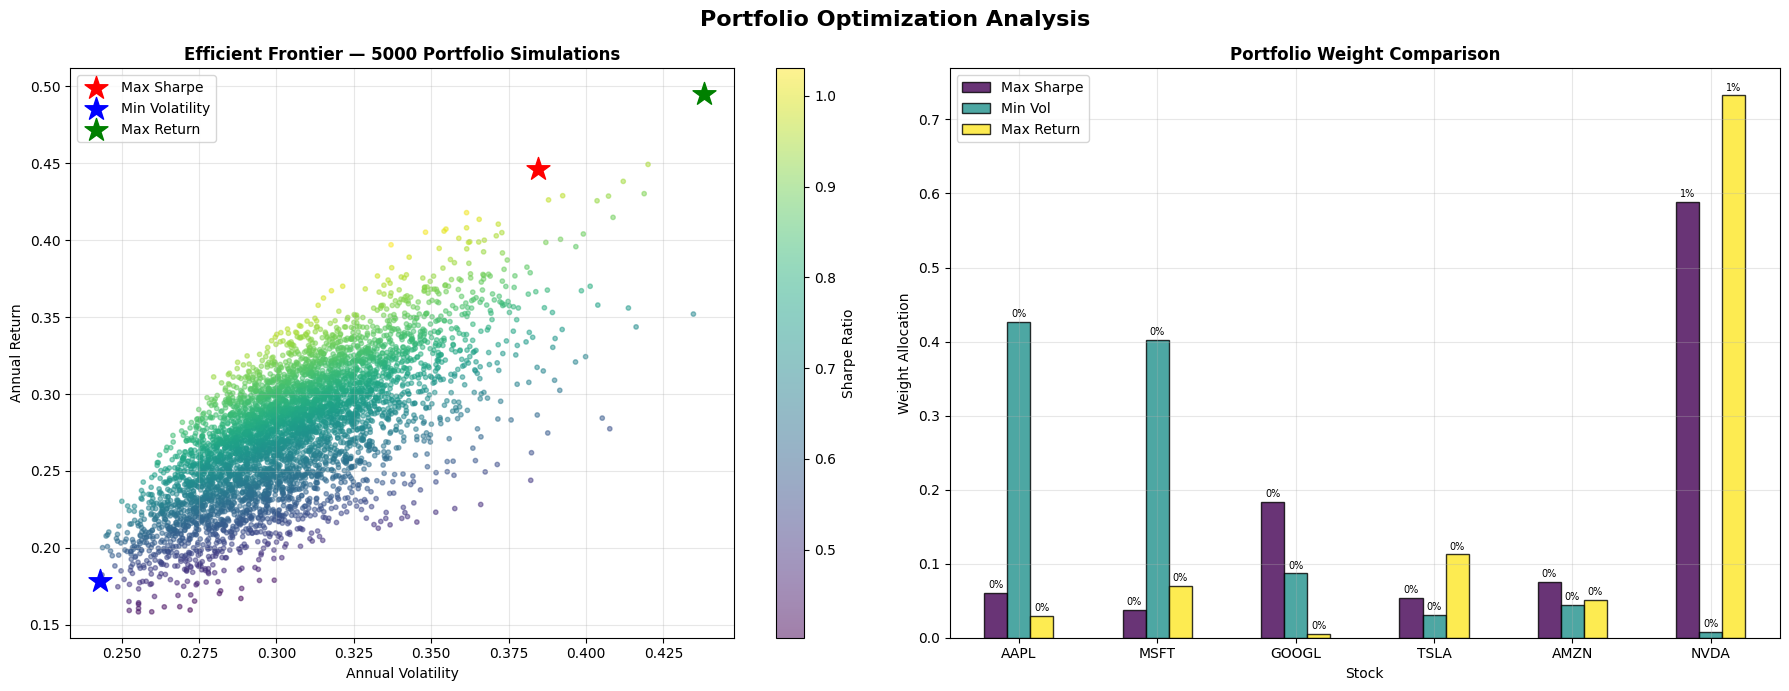

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Efficient Frontier
scatter = axes[0].scatter(
    simulation_df['Volatility'],
    simulation_df['Return'],
    c=simulation_df['Sharpe'],
    cmap='viridis',
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, ax=axes[0],
             label='Sharpe Ratio')

# Mark key portfolios
axes[0].scatter(
    max_sharpe_port['Volatility'],
    max_sharpe_port['Return'],
    color='red', marker='*',
    s=300, zorder=5,
    label='Max Sharpe'
)
axes[0].scatter(
    min_vol_port['Volatility'],
    min_vol_port['Return'],
    color='blue', marker='*',
    s=300, zorder=5,
    label='Min Volatility'
)
axes[0].scatter(
    max_return_port['Volatility'],
    max_return_port['Return'],
    color='green', marker='*',
    s=300, zorder=5,
    label='Max Return'
)

axes[0].set_title(
    'Efficient Frontier — 5000 Portfolio Simulations',
    fontweight='bold'
)
axes[0].set_xlabel('Annual Volatility')
axes[0].set_ylabel('Annual Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Portfolio Weight Comparison
weight_data = pd.DataFrame({
    'Max Sharpe' : [max_sharpe_port[t] for t in tickers],
    'Min Vol'    : [min_vol_port[t] for t in tickers],
    'Max Return' : [max_return_port[t] for t in tickers]
}, index=tickers)

weight_data.plot(
    kind='bar',
    ax=axes[1],
    colormap='viridis',
    alpha=0.8,
    edgecolor='black'
)
axes[1].set_title(
    'Portfolio Weight Comparison',
    fontweight='bold'
)
axes[1].set_ylabel('Weight Allocation')
axes[1].set_xlabel('Stock')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)

# Add percentage labels
for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt='%.0f%%',
        label_type='edge',
        fontsize=7,
        padding=2
    )

plt.suptitle(
    'Portfolio Optimization Analysis',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [27]:
# Create clean summary table
summary = pd.DataFrame({
    'Portfolio'  : [
        'Max Sharpe', 
        'Min Volatility', 
        'Max Return'
    ],
    'Annual Return' : [
        f"{max_sharpe_port['Return']:.2%}",
        f"{min_vol_port['Return']:.2%}",
        f"{max_return_port['Return']:.2%}"
    ],
    'Annual Vol' : [
        f"{max_sharpe_port['Volatility']:.2%}",
        f"{min_vol_port['Volatility']:.2%}",
        f"{max_return_port['Volatility']:.2%}"
    ],
    'Sharpe Ratio' : [
        f"{max_sharpe_port['Sharpe']:.2f}",
        f"{min_vol_port['Sharpe']:.2f}",
        f"{max_return_port['Sharpe']:.2f}"
    ]
})

print("=" * 60)
print("          PORTFOLIO COMPARISON SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print("=" * 60)

# Investor type recommendation
print("\nRECOMMENDED PORTFOLIO BY INVESTOR TYPE:")
print("-" * 60)
print("Conservative investor  → Minimum Volatility Portfolio")
print("                         Lowest risk, stable returns")
print("Moderate investor      → Maximum Sharpe Portfolio")
print("                         Best risk-adjusted returns")
print("Aggressive investor    → Maximum Return Portfolio")
print("                         Highest return, highest risk")
print("-" * 60)
print("\nFor educational purposes only — Not financial advice")

          PORTFOLIO COMPARISON SUMMARY
     Portfolio Annual Return Annual Vol Sharpe Ratio
    Max Sharpe        44.61%     38.44%         1.03
Min Volatility        17.89%     24.31%         0.53
    Max Return        49.47%     43.81%         1.02

RECOMMENDED PORTFOLIO BY INVESTOR TYPE:
------------------------------------------------------------
Conservative investor  → Minimum Volatility Portfolio
                         Lowest risk, stable returns
Moderate investor      → Maximum Sharpe Portfolio
                         Best risk-adjusted returns
Aggressive investor    → Maximum Return Portfolio
                         Highest return, highest risk
------------------------------------------------------------

For educational purposes only — Not financial advice


# Portfolio Optimization — Findings & Recommendations

## 1. Efficient Frontier Insights
- 5000 random portfolio simulations were run to find optimal allocations
- Red Star = Maximum Sharpe Portfolio (best risk/return balance)
- Blue Star = Minimum Volatility Portfolio (safest portfolio)
- Green Star = Maximum Return Portfolio (highest return possible)
- The green star sits far to the top right meaning maximum return comes with significantly higher risk
- The blue star sits bottom left meaning minimum volatility sacrifices a lot of return for safety
- The red star sits in the sweet spot delivering the best return per unit of risk taken

## 2. Annualized Returns by Stock
| Stock | Annual Return | Key Driver                          |
|-------|---------------|-------------------------------------|
| NVDA  | 59.38%        | AI chip demand explosion 2023-2025  |
| TSLA  | 33.93%        | High growth but extremely volatile  |
| GOOGL | 29.79%        | Solid growth stock                  |
| AAPL  | 17.67%        | Steady and reliable                 |
| MSFT  | 14.38%        | Consistent but slower growth        |
| AMZN  | 9.73%         | Weakest performer of the 6          |

## 3. Optimal Portfolio Allocations

### Maximum Sharpe Portfolio — Moderate Investors
- Return : 44.61% | Volatility : 38.44% | Sharpe : 1.03
- Model heavily favors NVDA because its return more than compensates for its risk
- GOOGL is second because it offers good returns with moderate volatility
- MSFT gets almost nothing despite low volatility because its returns are too low relative to others

| Stock | Allocation |
|-------|------------|
| NVDA  | 58.88%     |
| GOOGL | 18.36%     |
| AMZN  | 7.52%      |
| AAPL  | 6.08%      |
| TSLA  | 5.38%      |
| MSFT  | 3.79%      |

### Minimum Volatility Portfolio — Conservative Investors
- Return : 17.89% | Volatility : 24.31% | Sharpe : 0.53
- AAPL and MSFT dominate because they are the two least volatile stocks at 27.9% and 26.1%
- NVDA gets almost zero allocation despite high returns because its volatility is too high
- This portfolio sacrifices 27% of return to reduce risk by 14%

| Stock | Allocation |
|-------|------------|
| AAPL  | 42.71%     |
| MSFT  | 40.23%     |
| GOOGL | 8.70%      |
| AMZN  | 4.48%      |
| TSLA  | 3.08%      |
| NVDA  | 0.81%      |

### Maximum Return Portfolio — Aggressive Investors
- Return : 49.47% | Volatility : 43.81% | Sharpe : 1.02
- Model goes all in on NVDA and TSLA because they have the highest raw returns
- This is extremely concentrated and risky
- A bad quarter for NVDA would severely damage this portfolio
- Not recommended unless you have a very long time horizon and high risk tolerance

| Stock | Allocation |
|-------|------------|
| NVDA  | 73.24%     |
| TSLA  | 11.25%     |
| MSFT  | 6.97%      |
| AMZN  | 5.07%      |
| AAPL  | 2.97%      |
| GOOGL | 0.50%      |

## 4. Portfolio Comparison Summary
| Portfolio         | Annual Return | Volatility | Sharpe Ratio |
|-------------------|---------------|------------|--------------|
| Max Sharpe        | 44.61%        | 38.44%     | 1.03         |
| Min Volatility    | 17.89%        | 24.31%     | 0.53         |
| Max Return        | 49.47%        | 43.81%     | 1.02         |

Key observations:
- Max Sharpe and Max Return have almost identical Sharpe ratios (1.03 vs 1.02) meaning the extra 4.86% return from Max Return barely justifies the extra 5.37% volatility
- Min Volatility has the worst Sharpe ratio (0.53) meaning you are not being well compensated for the risk taken
- Max Sharpe is clearly the best balance for most investors

## 5. Final Recommendations by Investor Type
| Investor Type | Recommended Portfolio | Expected Return | Expected Risk |
|---------------|-----------------------|-----------------|---------------|
| Conservative  | Min Volatility        | 17.89%          | 24.31%        |
| Moderate      | Max Sharpe            | 44.61%          | 38.44%        |
| Aggressive    | Max Return            | 49.47%          | 43.81%        |

### Conservative Investor
- 42% AAPL + 40% MSFT + 8% GOOGL + 10% others
- Best for capital preservation and steady growth

### Moderate Investor
- 59% NVDA + 18% GOOGL + 23% others
- Best for long term wealth building with manageable risk

### Aggressive Investor
- 73% NVDA + 11% TSLA + 16% others
- Best for maximum growth seekers with high risk tolerance

## 6. Universal Warnings
- Past returns do not guarantee future results
- NVDA dominated 2020 to 2026 due to the AI boom and future periods may favor different stocks
- These portfolios are concentrated in tech and do not include bonds or other asset classes
- Always consider your personal financial situation before making investment decisions
- Rebalance your portfolio regularly as market conditions change

---
*Based on 5000 Monte Carlo simulations using 6 years of data (2020 to 2026)*
*For educational purposes only — Not financial advice*
